In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import spikeinterface.full as si
from pathlib import Path
import numpy as np

In [3]:
from configuration import base_path, figure_folder
global_name = 'sorters_simulation_other_probes'



study_folder = base_path / global_name / 'study'
si.set_global_job_kwargs(n_jobs=0.8)
study_folder

PosixPath('/mnt/data/sam/DataSpikeSorting/data_study_components_paper_v2/sorters_simulation_other_probes/study')

In [4]:

study = si.SorterStudy(study_folder)
study

SorterStudy study 
  datasets: 8 ['static_cambridgeneurotech#ASSY-158-H5_140_1800.s', 'drifting_cambridgeneurotech#ASSY-158-H5_140_1800.s', 'static_Neuropixels2-128_250_1800.s', 'drifting_Neuropixels2-128_250_1800.s', 'static_sinaps-128_250_1800s', 'drifting_sinaps-128_250_1800s', 'static_tetrode_10_1800.s', 'drifting_tetrode_10_1800.s']
  cases: 28 [('kilosort4', 'static', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('tridesclous2', 'static', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('spykingcircus2', 'static', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('lupin', 'static', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('kilosort4', 'drifting', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('tridesclous2', 'drifting', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('spykingcircus2', 'drifting', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('lupin', 'drifting', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('kilosort4', 'static', 'Neuropixels2-128_250_1800.s'), ('tridesclous2'

In [5]:
study.datasets.keys()

dict_keys(['static_cambridgeneurotech#ASSY-158-H5_140_1800.s', 'drifting_cambridgeneurotech#ASSY-158-H5_140_1800.s', 'static_Neuropixels2-128_250_1800.s', 'drifting_Neuropixels2-128_250_1800.s', 'static_sinaps-128_250_1800s', 'drifting_sinaps-128_250_1800s', 'static_tetrode_10_1800.s', 'drifting_tetrode_10_1800.s'])

In [6]:
colors_by_levels = {
    ('kilosort4', 'static'): "#DA6B03",
    ('tridesclous2', 'static'): "#9F1272",
    ('lupin', 'static'): "#509403",
    ('spykingcircus2', 'static'): "#F1E100",

    ('kilosort4', 'drifting'): "#FCB26E",    
    ('tridesclous2', 'drifting'): "#F96FCD",
    ('spykingcircus2', 'drifting'): "#F0E988",
    ('lupin', 'drifting'): "#81F255",

}

study.colors_by_case = {}
for case_key in study.cases.keys():
    study.colors_by_case[case_key] = colors_by_levels[case_key[:2]]

study.colors_by_levels[('sorter_name', 'drifting')] = colors_by_levels

# print(study.colors_by_case)
# study.labels_by_levels[('sorter_name', 'drifting')] = {
#     ('kilosort4', 'static'): 'kilosort4 | static',
#     ('tridesclous2', 'static'): 'tridesclous2 | static',
#     ('spykingcircus2', 'static'): 'spykingcircus2 | static',
#     # ('kilosort4like', 'static'): 'kilosort-like | static',
#     ('lupin', 'static'): 'lupin | static',

#     ('tridesclous2', 'drifting'): 'tridesclous2 | motion-corrected',

#     ('kilosort4', 'drifting'): 'kilosort4 | motion-corrected',    
#     ('spykingcircus2', 'drifting'): 'spykingcircus2 | motion-corrected',
#     # ('kilosort4like', 'drifting'): 'kilosort-like | motion-corrected',
#     ('lupin', 'drifting'): 'lupin | motion-corrected',

# }

[('kilosort4', 'static', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('tridesclous2', 'static', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('spykingcircus2', 'static', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('lupin', 'static', 'cambridgeneurotech#ASSY-158-H5_140_1800.s')]
static_cambridgeneurotech#ASSY-158-H5_140_1800.s
[('kilosort4', 'drifting', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('tridesclous2', 'drifting', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('spykingcircus2', 'drifting', 'cambridgeneurotech#ASSY-158-H5_140_1800.s'), ('lupin', 'drifting', 'cambridgeneurotech#ASSY-158-H5_140_1800.s')]
[('kilosort4', 'static', 'Neuropixels2-128_250_1800.s'), ('tridesclous2', 'static', 'Neuropixels2-128_250_1800.s'), ('spykingcircus2', 'static', 'Neuropixels2-128_250_1800.s'), ('lupin', 'static', 'Neuropixels2-128_250_1800.s')]
static_Neuropixels2-128_250_1800.s
[('kilosort4', 'drifting', 'Neuropixels2-128_250_1800.s'), ('tridesclous2', 'drifting', 'Neuropixels2-128_250

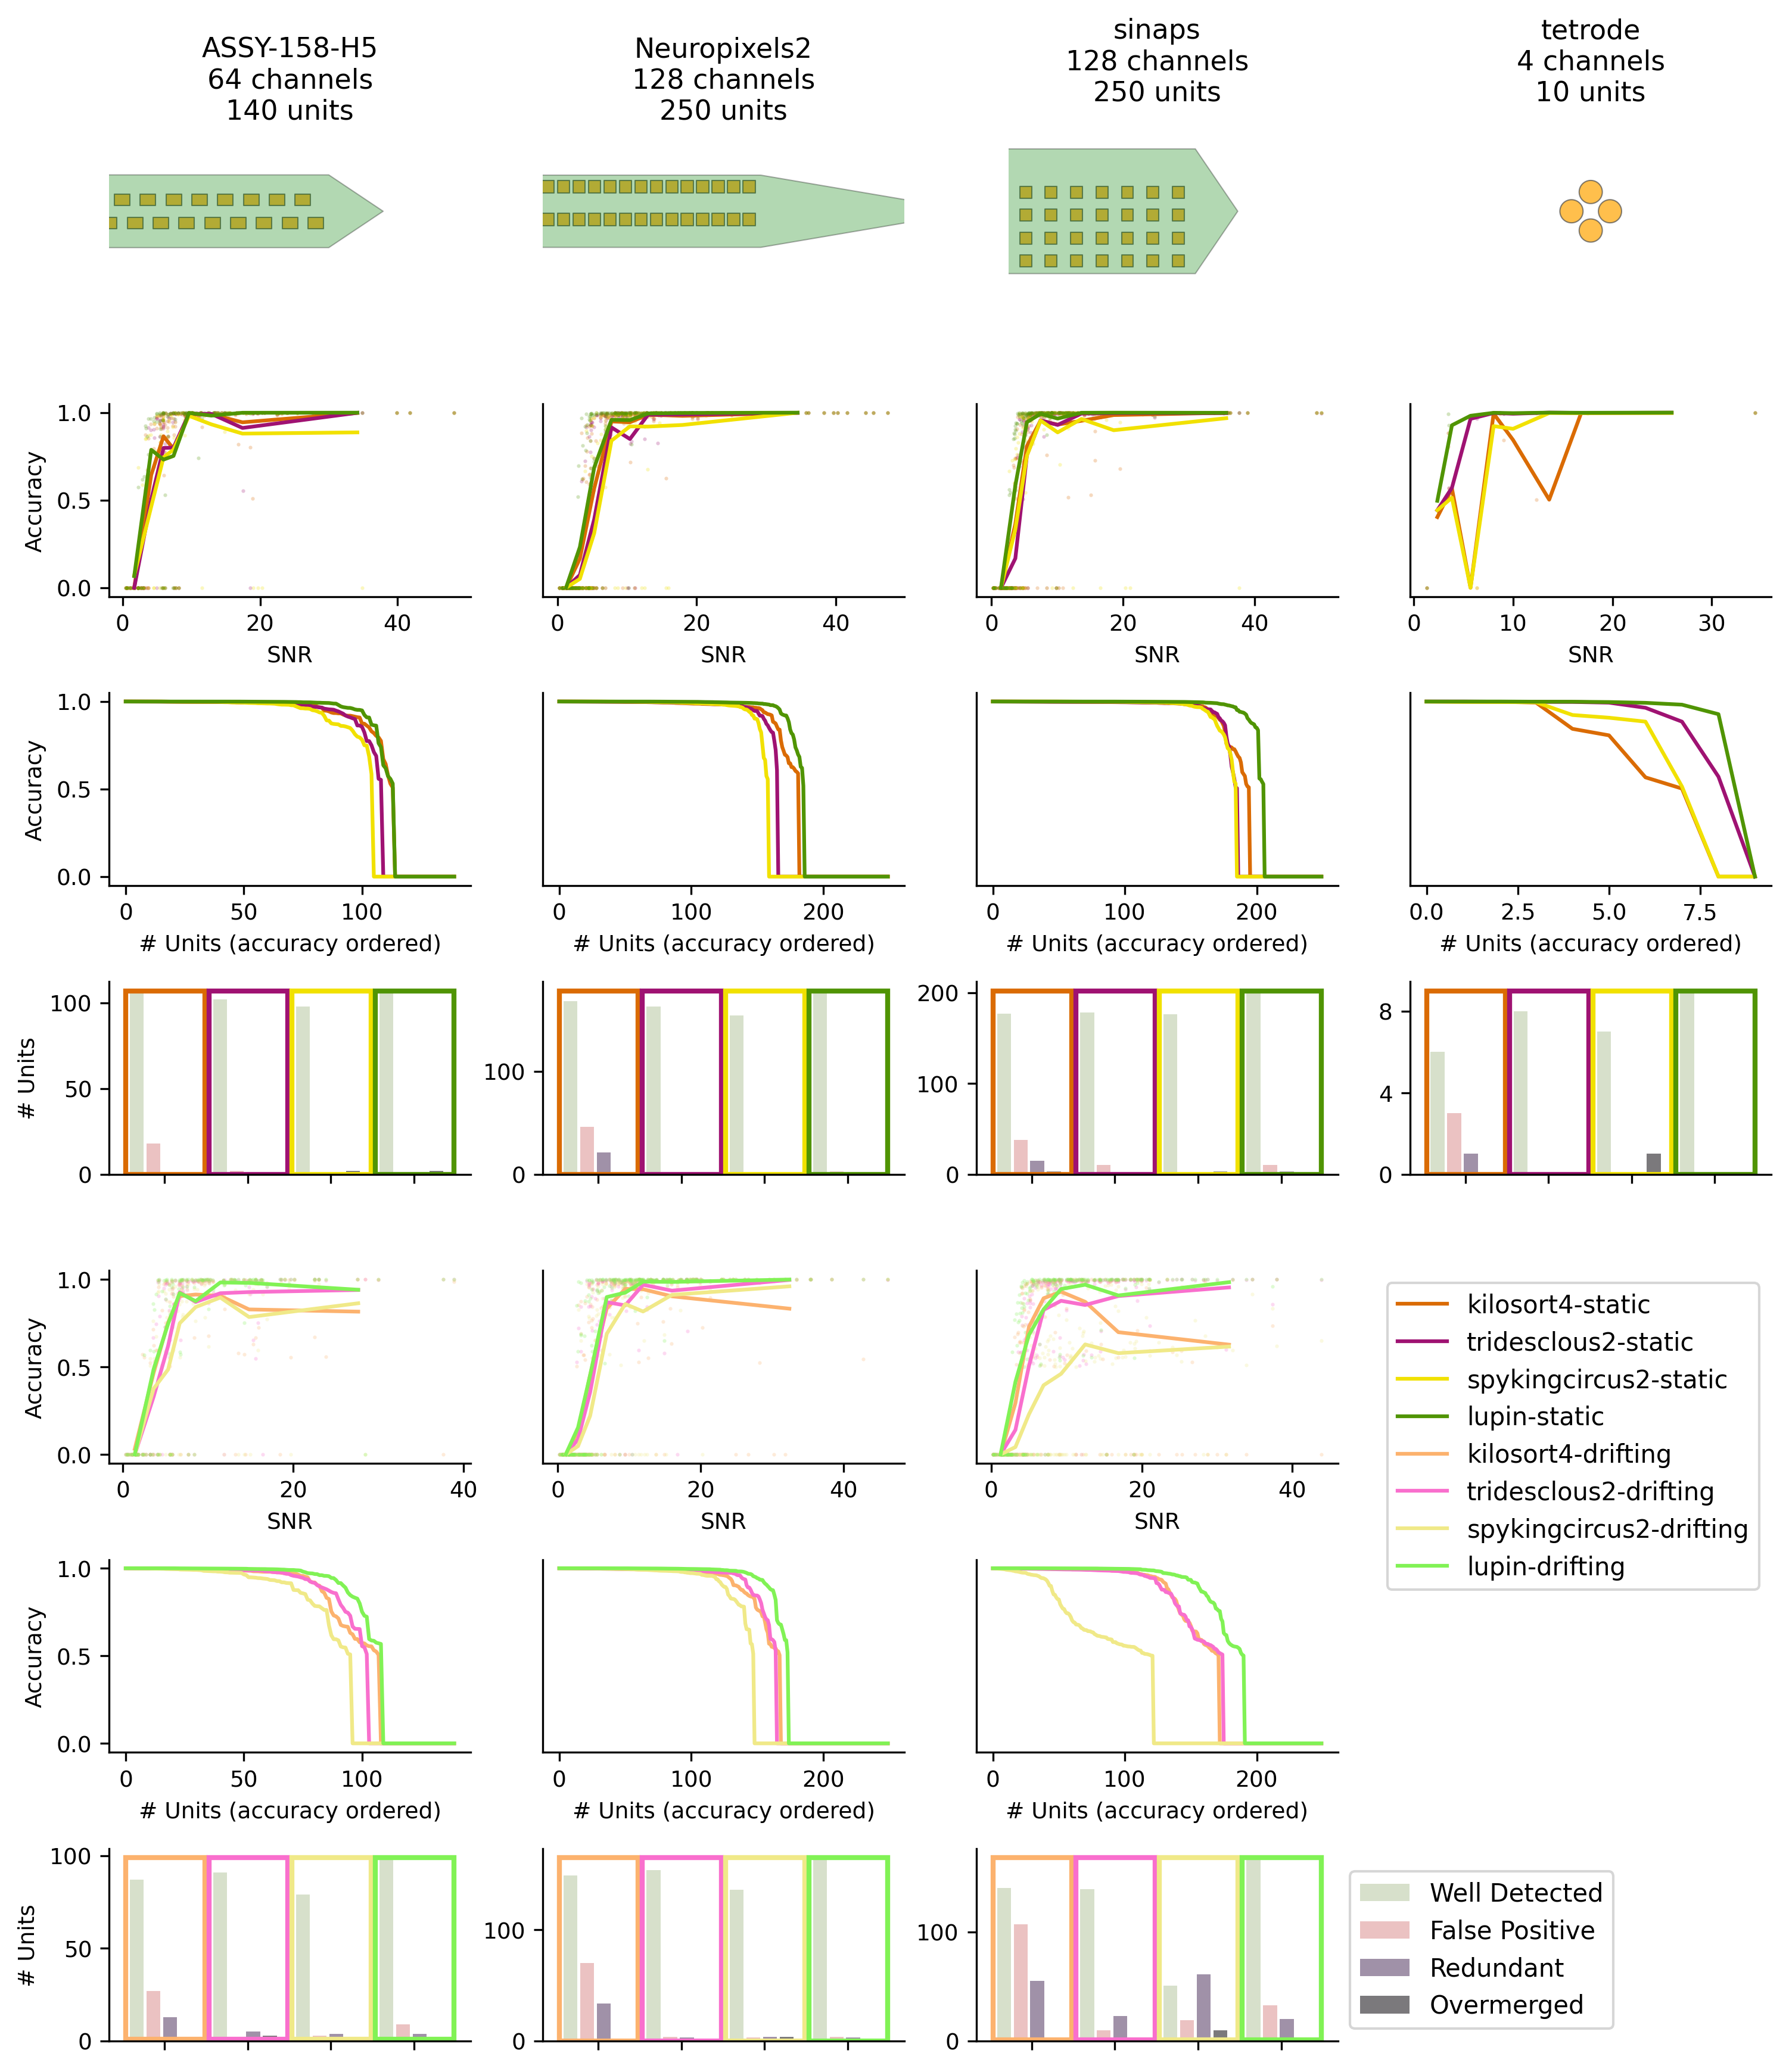

In [16]:
%matplotlib inline
myparams = {
    'axes.titlesize' : 11,
    'axes.labelsize' : 9,
    'legend.fontsize': 10,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
}


import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
from spikeinterface.benchmark.benchmark_plot_tools import despine, clean_axis, plot_study_legend, plot_performances_ordered
from matplotlib.gridspec import GridSpec

from probeinterface.plotting import plot_probe


dataset_names = [
    'cambridgeneurotech#ASSY-158-H5_140_1800.s',
    'Neuropixels2-128_250_1800.s',
    'sinaps-128_250_1800s',
    'tetrode_10_1800.s',
] 

n = len(dataset_names)

with mpl.rc_context(myparams):

    fig = plt.figure(figsize=(12, 14), dpi=300)

    gs = GridSpec(7, n, hspace=0.5)
    

    for i, dataset_name in enumerate(dataset_names):

        ax0 = fig.add_subplot(gs[0, i])

        for j, motion_case in enumerate(["static", "drifting"]):
            if motion_case == "drifting" and "tetrode" in dataset_name:
                continue

            data_name = f"{motion_case}_{dataset_name}"


            

            case_keys = [k for k in study.cases.keys() if k[2] == dataset_name and k[1] == motion_case]
            print(case_keys)
            
            
            
            ax1 = fig.add_subplot(gs[1 + j*3, i])
            ax2 = fig.add_subplot(gs[2 + j*3, i])
            ax3 = fig.add_subplot(gs[3 + j*3, i])


            if motion_case == 'static':
                
                
                data_key = study.cases[case_keys[0]]['dataset']
                print(data_key)
                rec, sorting = study.datasets[data_key]
                probe = rec.get_probe().copy()
                probe.rotate(-90)
                plot_probe(probe, ax=ax0)
                if probe.get_contact_count() > 4:
                    x = probe.contact_positions[:, 0]
                    l1 = x.max() + 150
                    l0 = l1 - 350
                    ax0.set_xlim(l0, l1)

                # ax0.set_xlim(-100, 0)
                clean_axis(ax0)
                data_name = dataset_name.split('_')[0]
                if '#' in data_name:
                    data_name = data_name.split('#')[1]
                data_name = data_name.replace('-128', '')
                nchans = rec.get_num_channels()
                nunits = sorting.get_num_units()
                title = f'{data_name}\n{nchans} channels\n{nunits} units'
                ax0.set_title(title)
                ax0.set_xlabel(None)
                ax0.set_ylabel(None)


            
            _ = study.plot_performances_vs_snr(case_keys=case_keys, 
                                            performance_names=['accuracy'],
                                            #    show_scatter=False,
                                                with_sigmoid_fit=False,
                                                show_average_by_bin=True,
                                                scatter_size=1,
                                                scatter_alpha=0.25,
                                                num_bin_average=8,
                                                # metric_dataset_reference='static',
                                                # levels_to_group_by=['sorter_name', 'drifting'],
                                                show_legend=False, axs=[ax1])
            ax1.set_xlabel('SNR')

            study.plot_performances_ordered(case_keys=case_keys, performance_names=['accuracy'],
                                            # levels_to_group_by=['sorter_name', 'drifting'],
                                            show_legend=False, axs=[ax2])
            ax2.set_title(None)
            ax2.set_xlabel('# Units (accuracy ordered)')
            

            count_colors = dict(
                num_well_detected="#D7E0CB",
                num_false_positive="#EBC2C2",
                num_redundant="#A091A8",
                num_overmerged="#7B797C",
            )

            _ = study.plot_unit_counts(case_keys=case_keys,  ax=ax3,
                                    columns=['num_well_detected', 'num_false_positive', 'num_redundant', 'num_overmerged',],
                                        # levels_to_group_by=['sorter_name', 'drifting'],
                                        revert_bad=False,
                                        xticks_rotation=0.,
                                        colors=count_colors,
                                        show_legend=False,
                                    )
            if i == len(dataset_names) - 2 and motion_case == 'drifting':
                ax3.legend(loc='lower left', bbox_to_anchor=(1, 0))

            ax3.set_xticklabels([])

            
            if i == 0:
                for ax in (ax1, ax2):
                    ax.set_yticks([0, 0.5, 1.])
                    ax.set_ylabel('Accuracy')
                ax3.set_ylabel('# Units')
            else:
                for ax in (ax1, ax2):
                    ax.set_yticks([])
                    ax.set_ylabel(None)
                ax3.set_ylabel(None)
            
            if i == 3:
                # tetrode
                ax3.set_yticks([0, 4, 8])

            despine(ax1)
            despine(ax2)
            despine(ax3)

    # _ = study.plot_performances_ordered(case_keys=case_keys)

    ax_legend = fig.add_subplot(gs[4:6, len(dataset_names) - 1])
    all_cases = list(study.cases.keys())
    plot_study_legend(study, case_keys=all_cases,
                        levels_to_group_by=['sorter_name', 'drifting'],
                        ax=ax_legend)

    # fig.tight_layout(pad=0.0)


    fig.savefig(figure_folder / 'figure_sorters_other_probes.png')
    fig.savefig(figure_folder / 'figure_sorters_other_probes.pdf')
